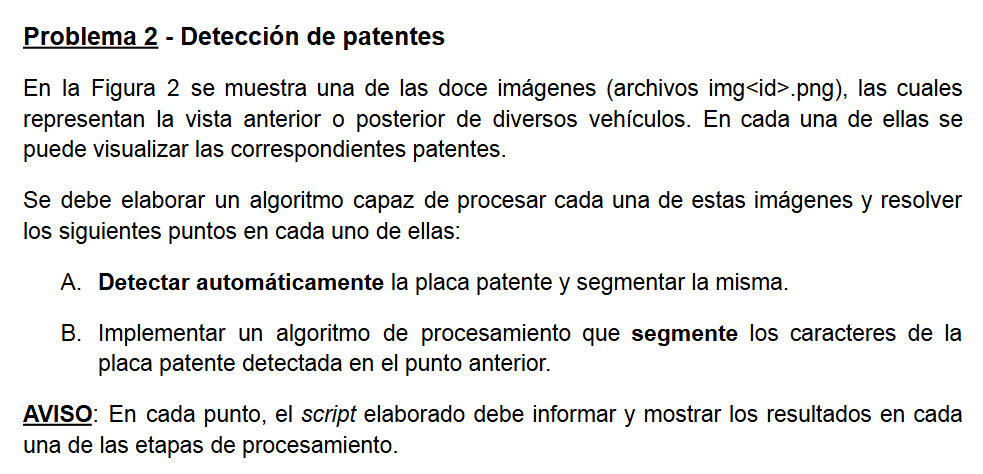

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

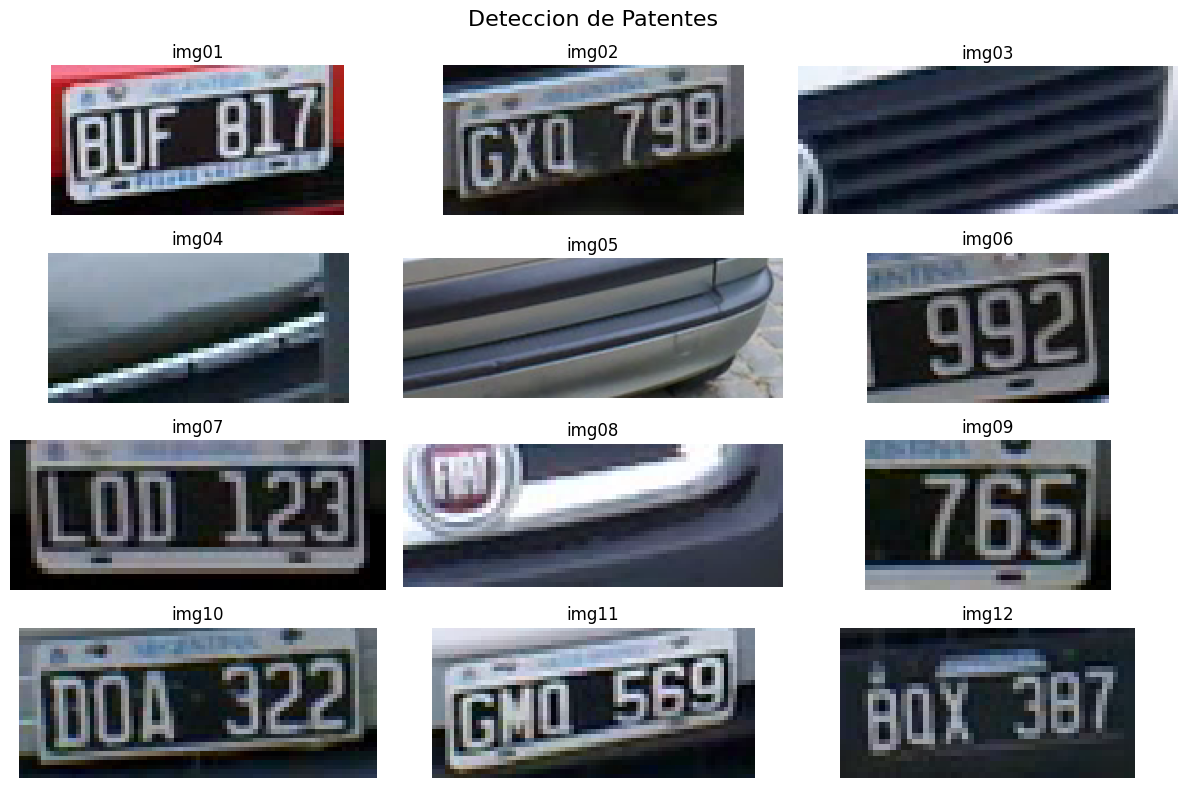

In [4]:
def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    #thresh = cv2.dilate(cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3))), None)

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        if 1.5 < aspect < 5.0 and w*h > 80 and 15 < h < 100:
            candidatos.append((x, y, w, h))

    if not candidatos: return None
    

    #seleccion
    H, W = img.shape[:2]
    
    def calcular_puntaje(r):
        x, y, w, h = r
        # Puntos por ratio (ideal 3.0) + Posición Y (centro-abajo) + Centrado X
        s_ratio = max(0, 10 - abs(w/h - 3.0) * 2)
        s_pos_y = 5 if 0.3 < y/H < 0.85 else 0
        s_centrado = 3 if abs(W//2 - (x + w//2)) < W*0.2 else 0
        return s_ratio + s_pos_y + s_centrado

    x, y, w, h = max(candidatos, key=calcular_puntaje)

    pad = 5
    return img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]




resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    
    if recorte is not None:
        resultados_crops.append(recorte)
        nombres_archivos.append(f"img{i:02d}")
    else:
        placeholder = np.zeros((50, 150, 3), dtype=np.uint8)
        resultados_crops.append(placeholder)
        nombres_archivos.append(f"img{i:02d} (Falló)")


fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Deteccion de Patentes', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')

plt.tight_layout()
plt.show()

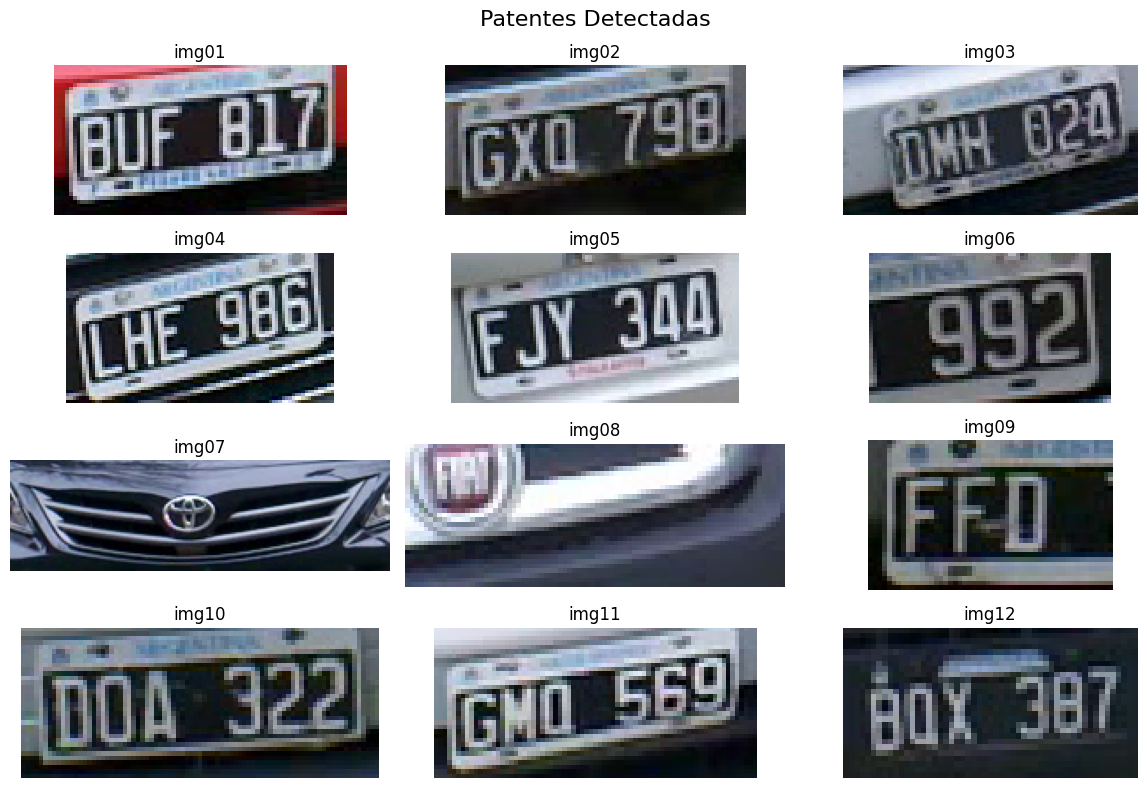

In [18]:
def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        
        if 1.5 < aspect < 6.0 and w*h > 80 and 12 < h < 120:
            candidatos.append((x, y, w, h))

    if not candidatos: 
        return None

    H, W = img.shape[:2]
    
    #selecion
    def calcular_puntaje(r):
        x, y, w, h = r
        
        #Centrado Horizontal
        center_x = x + w//2
        dist_center_x = abs(W//2 - center_x)
        
        if dist_center_x < W * 0.15: s_center_x = 15 
        elif dist_center_x < W * 0.35: s_center_x = 5
        else: s_center_x = -5 
            
        #Proporción
        aspect = w / h
        s_aspect = max(0, 15 - abs(aspect - 2.75) * 5)
        
        #Densidad
        roi_thresh = thresh[y:y+h, x:x+w]
        pixeles_blancos = cv2.countNonZero(roi_thresh)
        area = w * h
        ratio_relleno = pixeles_blancos / area
        
        if 0.15 < ratio_relleno < 0.70: s_fill = 5
        else: s_fill = -10 

        #Posición Vertical
        center_y = y + h//2
        s_pos_y = 5 if 0.30 * H < center_y < 0.85 * H else -5

        #Tamaño
        s_size = 5 if area > (W*H)*0.005 else 0

        return s_center_x + s_aspect + s_fill + s_pos_y + s_size

    ganador = max(candidatos, key=calcular_puntaje)
    x, y, w, h = ganador

    pad = 5
    recorte = img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]

    return recorte



resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    resultados_crops.append(recorte)
    nombres_archivos.append(f"img{i:02d}")



fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Patentes Detectadas', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')

plt.tight_layout()
plt.show()

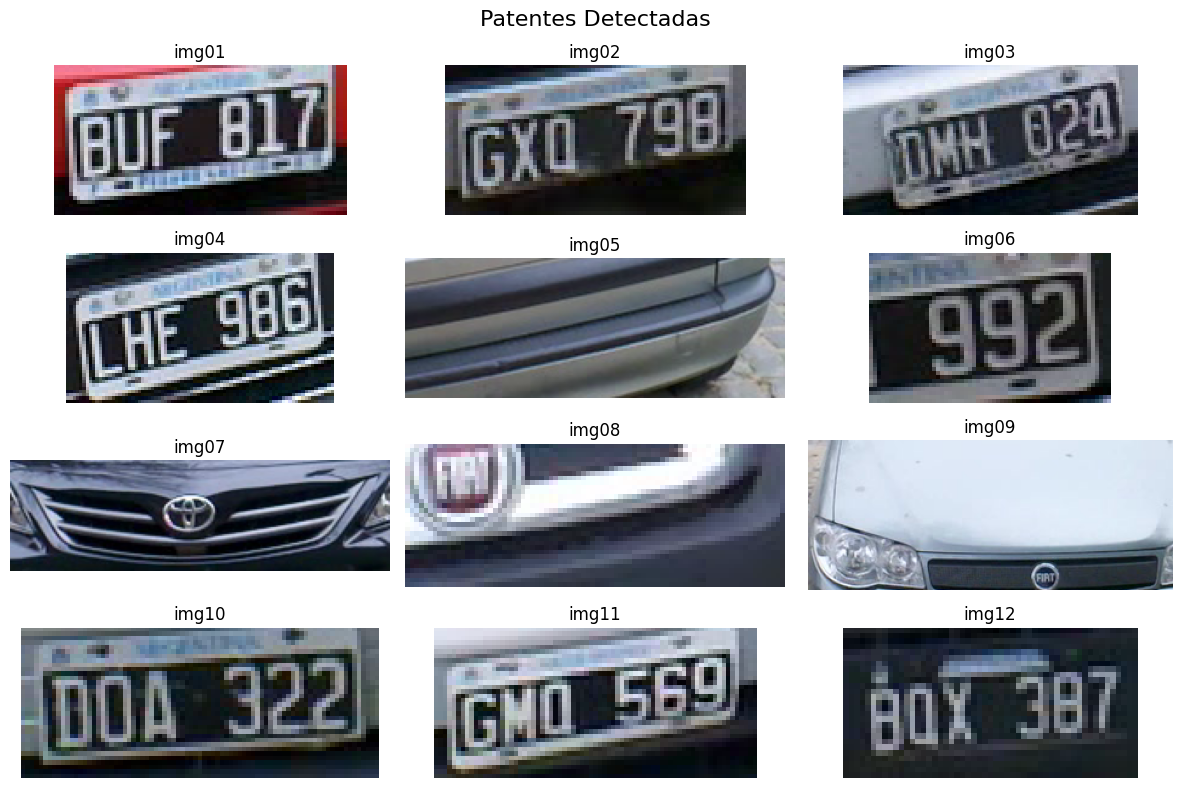

In [21]:
import cv2
import matplotlib.pyplot as plt

def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        
        if 1.5 < aspect < 6.0 and w*h > 80 and 12 < h < 120:
            candidatos.append((x, y, w, h))

    if not candidatos: 
        return None

    H, W = img.shape[:2]
    
    # seleccion
    def calcular_puntaje(r):
        x, y, w, h = r
        
        #Centrado Horizontal
        center_x = x + w//2
        dist_center_x = abs(W//2 - center_x)
        
        if dist_center_x < W * 0.15: s_center_x = 15 
        elif dist_center_x < W * 0.35: s_center_x = 5
        else: s_center_x = -5 
            
        #Proporcion
        aspect = w / h
        s_aspect = max(0, 15 - abs(aspect - 2.75) * 5)
        
        #Posición Vertical
        center_y = y + h//2
        s_pos_y = 5 if 0.30 * H < center_y < 0.85 * H else -5

        #Tamaño
        area = w * h
        s_size = 5 if area > (W*H)*0.005 else 0

        return s_center_x + s_aspect + s_pos_y + s_size

    ganador = max(candidatos, key=calcular_puntaje)
    x, y, w, h = ganador

    pad = 5
    recorte = img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]

    return recorte




resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    resultados_crops.append(recorte)
    nombres_archivos.append(f"img{i:02d}")


fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Patentes Detectadas', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

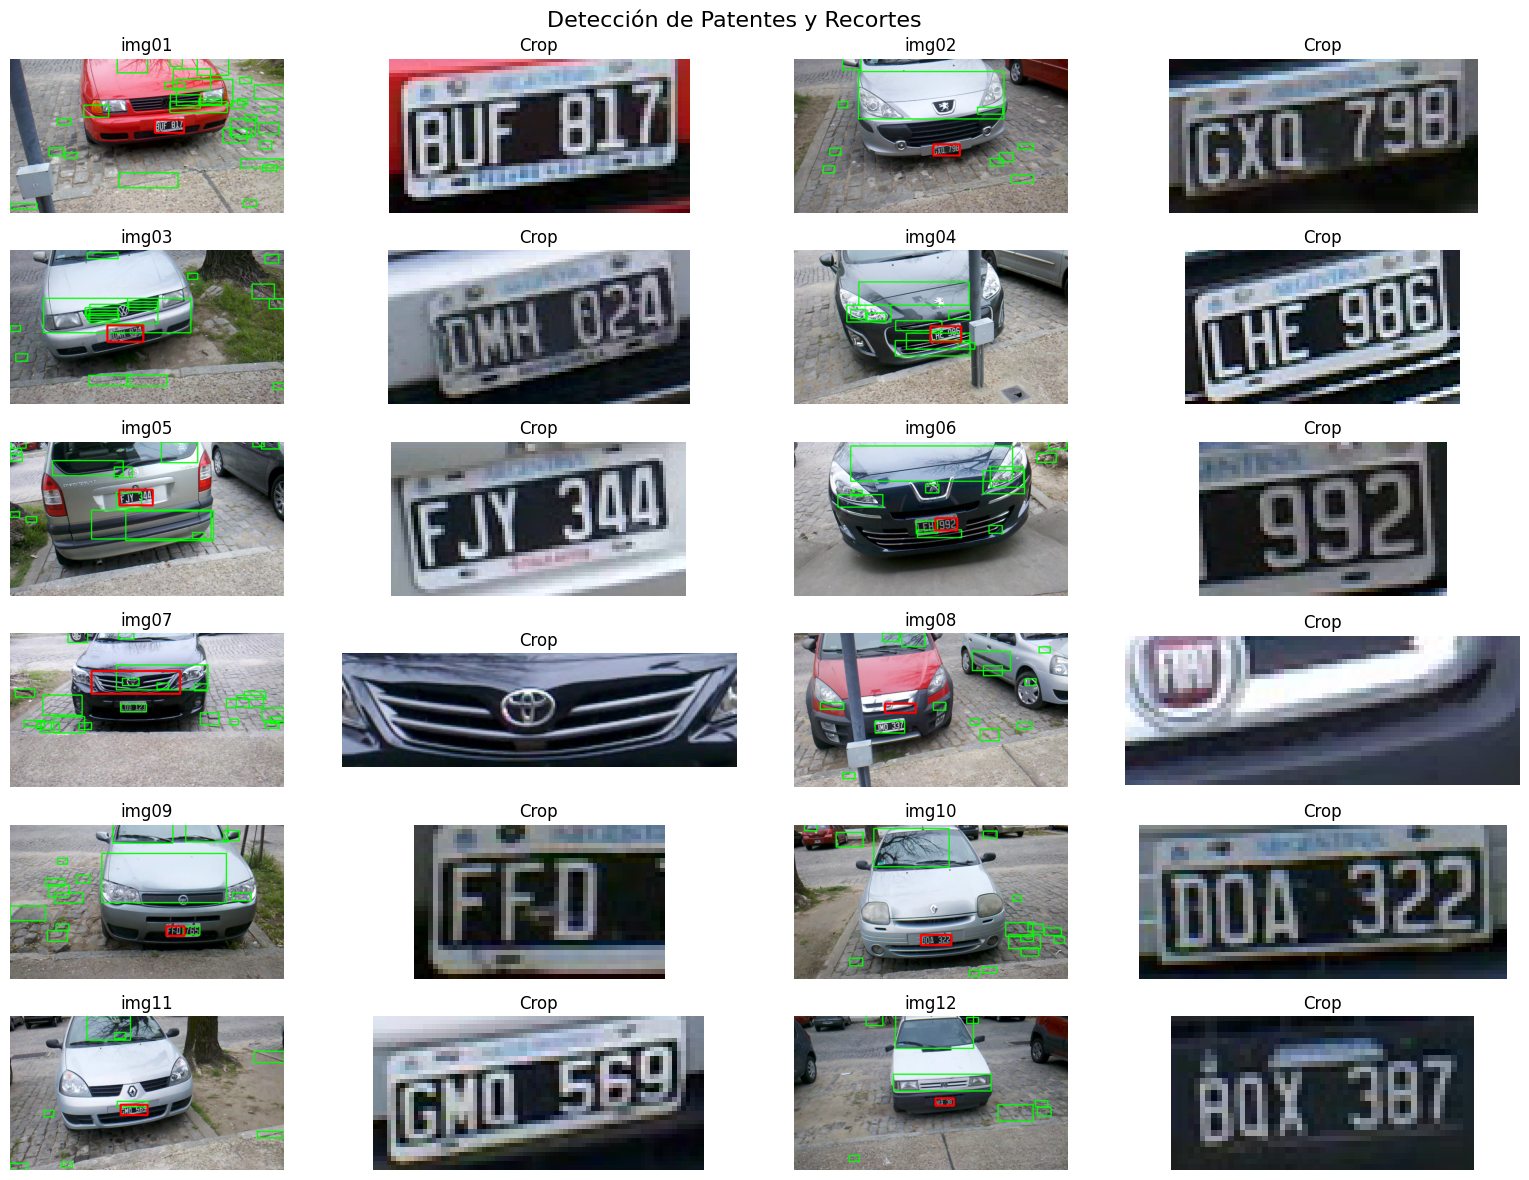

In [ ]:
def obtener_recorte_y_debug(path):
    img = cv2.imread(path)
    if img is None: return None, None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []
    img_debug = img.copy()

    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h   
        #filtrar rectangulos
        if 1.5 < aspect < 6.0 and w*h > 80 and 12 < h < 120:
            candidatos.append((x, y, w, h))
            cv2.rectangle(img_debug, (x, y), (x+w, y+h), (0, 255, 0), 2)

    if not candidatos: 
        return None, img_debug

    H, W = img.shape[:2]
    
    #seleccion
    def calcular_puntaje(r):
        x, y, w, h = r
        
        #centrado horizontal
        center_x = x + w//2
        dist_center_x = abs(W//2 - center_x)
        
        if dist_center_x < W * 0.15:
            s_center_x = 15 
        elif dist_center_x < W * 0.35:
            s_center_x = 5
        else:
            s_center_x = -5 
            
        #proporcion
        aspect = w / h
        s_aspect = max(0, 15 - abs(aspect - 2.75) * 5)
        
        #densidad
        roi_thresh = thresh[y:y+h, x:x+w]
        pixeles_blancos = cv2.countNonZero(roi_thresh)
        area = w * h
        ratio_relleno = pixeles_blancos / area
        
        if 0.15 < ratio_relleno < 0.70:
            s_fill = 5
        else:
            s_fill = -10 

        #posicion vertical
        center_y = y + h//2
        s_pos_y = 5 if 0.30 * H < center_y < 0.85 * H else -5

        #tamaño
        s_size = 5 if area > (W*H)*0.005 else 0

        total = s_center_x + s_aspect + s_fill + s_pos_y + s_size
        return total

    
    ganador = max(candidatos, key=calcular_puntaje)
    x, y, w, h = ganador

    
    cv2.rectangle(img_debug, (x, y), (x+w, y+h), (0, 0, 255), 3)

    pad = 5
    recorte = img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]

    return recorte, img_debug



lista_datos = [] 

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte, img_con_cajas = obtener_recorte_y_debug(nombre_archivo)
    
    if img_con_cajas is None:
        img_con_cajas = np.zeros((100, 100, 3), dtype=np.uint8)
    
    if recorte is None:
        recorte = np.zeros((50, 150, 3), dtype=np.uint8) # Placeholder negro para el crop
        
    lista_datos.append((f"img{i:02d}", img_con_cajas, recorte))


fig, axes = plt.subplots(6, 4, figsize=(16, 12))
fig.suptitle('Detección de Patentes y Recortes', fontsize=16)

axes_flat = axes.ravel() 

for i in range(len(lista_datos)):
    nombre, img_full, img_crop = lista_datos[i]
    idx_full = i * 2
    idx_crop = i * 2 + 1
    
    if idx_full < len(axes_flat):
        # 1. Dibujar Imagen Completa
        ax_main = axes_flat[idx_full]
        img_rgb = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB)
        ax_main.imshow(img_rgb)
        ax_main.set_title(nombre)
        ax_main.axis('off')
        
        # 2. Dibujar Recorte
        ax_crop = axes_flat[idx_crop]
        crop_rgb = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)
        ax_crop.imshow(crop_rgb)
        ax_crop.set_title("Crop")
        ax_crop.axis('off')

plt.tight_layout()
plt.show()